# Comparación de curvas H/V medias entre sitios

Superpone las curvas H/V medias de los 15 puntos de la bitácora de campo (19, 20 y 22 de mayo de 2023) para identificar tendencias comunes.

Cada curva se recalcula con el perfil de procesamiento que eligió el cribado de sesiones (`session_peak_summary.csv`), en la banda 0.2–50 Hz y con búsqueda de pico en 1–50 Hz. Así f0 y A0 coinciden con [hvsr_sites_f0_A0.csv](../../outputs/other_sessions_peak_screen/hvsr_sites_f0_A0.csv). Para la Terraza 28 se usa el perfil principal de su notebook: ventanas de 30 s, anti-trigger, crest factor 20, detrend lineal, B=40, squared average y FDR.

Por encima de 50 Hz no se muestra nada: el muestreo es de 200 Hz y el filtro anti-alias actúa cerca de Nyquist. Ninguna curva cumple todos los criterios SESAME.

In [1]:
from pathlib import Path
import json, sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

WORKING_DIR = Path.cwd().resolve()
ROOT = next(f for f in (WORKING_DIR, *WORKING_DIR.parents)
            if (f / 'utils/hvsr_tools.py').is_file() and (f / 'data').is_dir())
sys.path.insert(0, str(ROOT))
from utils import hvsr_tools as hv
from utils import plotting as hp

SCREEN_DIR = ROOT / 'outputs/other_sessions_peak_screen'
OUTPUT_DIR = ROOT / 'outputs/site_comparison'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

sites = pd.read_csv(SCREEN_DIR / 'session_sites.csv')
screen = pd.read_csv(SCREEN_DIR / 'session_peak_summary.csv').set_index('session_id')
table = pd.read_csv(SCREEN_DIR / 'hvsr_sites_f0_A0.csv')

profiles = {}
for sid in sites['session_id']:
    b = screen.loc[sid]
    profiles[sid] = dict(
        window_length_s=float(b['best_window_length_s']),
        anti_trigger=bool(b['best_anti_trigger']),
        max_crest_factor=None if pd.isna(b['best_max_crest_factor']) else float(b['best_max_crest_factor']),
        detrend=b['best_detrend'],
        smoothing_bandwidth=float(b['best_smoothing_bandwidth']),
        horizontal_combination=b['best_horizontal_combination'],
        frequency_domain_rejection=bool(b['best_frequency_domain_rejection']),
    )
T28 = 'CBUCF_titanSMA_1614_20230519_213500_02'
profiles[T28] = dict(window_length_s=30.0, anti_trigger=True, max_crest_factor=20.0, detrend='linear',
                     smoothing_bandwidth=40.0, horizontal_combination='squared_average',
                     frequency_domain_rejection=True)
site_of = dict(zip(sites['session_id'], sites['site'])) | {T28: 'Terraza 28'}

manifest_sessions = {}
for path in sorted((ROOT / 'data/accelerometer').glob('*/sessions.json')):
    for item in json.loads(path.read_text())['sessions']:
        manifest_sessions[item['session_id']] = item

BASE = dict(overlap_pct=0.0, window_selection='continuous', sta_s=2.0, lta_s=30.0,
            sta_lta_min=0.1, sta_lta_max=3.0, sta_lta_method='vector', sta_lta_amplitude='abs',
            transient_padding_s=2.0, filter_corners_hz=(None, None), taper_pct_per_side=5.0,
            smoothing='konno_and_ohmachi', fmin=0.2, fmax=50.0, n_frequencies=900,
            frequency_spacing='log', peak_range_hz=(1.0, 50.0), fdr_n=2.5)
print(f'{len(profiles)} sesiones a procesar')

15 sesiones a procesar


In [2]:
curves, rows = {}, []
for sid, prof in profiles.items():
    s = manifest_sessions[sid]
    record = hv.load_record([ROOT / p for p in s['input_files']], starttime=s['starttime'], endtime=s['endtime'])
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', RuntimeWarning)
        result = hv.run_hvsr(record, hv.HVSRParams(**BASE, **prof))
        quality = hv.assess_sesame_quality(result, time_blocks=4)
    start = pd.Timestamp(s['starttime']).tz_convert('America/Bogota')
    curves[sid] = pd.Series(np.asarray(result.mean_curve), index=np.asarray(result.frequency))
    rows.append({'session_id': sid, 'Lugar (bitácora)': site_of[sid], 'Inicio': start.strftime('%Y-%m-%d %H:%M'),
                 'f0': result.peak[0], 'A0': result.peak[1],
                 'Claridad': f"{quality['metrics']['clarity_count']}/6", 'n_ventanas': result.summary()['n_windows']})
recomputed = pd.DataFrame(rows).sort_values('Inicio').reset_index(drop=True)
display(recomputed.round(2))

13/34 windows | f0=14.63867 Hz | A0=1.33513
25/51 windows | f0=47.31120 Hz | A0=2.94275
66/106 windows | f0=1.20938 Hz | A0=1.36224


21/33 windows | f0=11.45007 Hz | A0=0.79838
42/46 windows | f0=2.57421 Hz | A0=0.88641
37/42 windows | f0=14.91090 Hz | A0=0.87079
26/34 windows | f0=23.63493 Hz | A0=2.06738
33/33 windows | f0=18.48675 Hz | A0=1.29163


59/68 windows | f0=16.15025 Hz | A0=1.04040
50/90 windows | f0=1.13733 Hz | A0=2.42583
3/43 windows | f0=14.28342 Hz | A0=1.31080
74/83 windows | f0=12.63239 Hz | A0=0.97780


47/82 windows | f0=46.44745 Hz | A0=1.46971
58/84 windows | f0=1.05006 Hz | A0=3.51119
26/48 windows | f0=11.17220 Hz | A0=1.40778


,session_id,Lugar (bitácora),Inicio,f0,A0,Claridad,n_ventanas
0,CBUCF_titanSMA_1614_20230519_213500_02,Terraza 28,2023-05-19 16:35,11.17,1.41,3/6,26
1,CBUCF_titanSMA_1614_20230519_221100_01,Terraza 27,2023-05-19 17:11,14.64,1.34,5/6,13
2,CBUCF_titanSMA_1614_20230519_224800_01,Terraza 32,2023-05-19 17:48,47.31,2.94,5/6,25
3,CBUCF_titanSMA_1614_20230519_232900_01,Terraza sin número frente a la rana,2023-05-19 18:29,1.21,1.36,4/6,66
4,CBUCF_titanSMA_1614_20230520_103800_02,Terraza 39E (abajo helipuerto),2023-05-20 05:38,11.45,0.80,3/6,21
5,CBUCF_titanSMA_1614_20230520_110900_01,Terraza 40E,2023-05-20 06:09,2.57,0.89,3/6,42
6,CBUCF_titanSMA_1614_20230520_113700_01,Terraza 41E,2023-05-20 06:37,14.91,0.87,4/6,37
7,CBUCF_titanSMA_1614_20230520_120239_02,Terraza 44,2023-05-20 07:03,23.63,2.07,5/6,26
8,CBUCF_titanSMA_1614_20230520_123500_02,Terraza 46,2023-05-20 07:37,18.49,1.29,4/6,33
9,CBUCF_titanSMA_1614_20230520_200700_03,"Exterior al este de Terraza 74, corona muro ba...",2023-05-20 15:13,16.15,1.04,3/6,59


In [3]:
check = recomputed.merge(table, on='Lugar (bitácora)', suffixes=('', '_tabla'))
check['dif_f0_%'] = 100 * (check['f0'] - check['f0_tabla']).abs() / check['f0_tabla']
check['dif_A0'] = (check['A0'] - check['A0_tabla']).abs()
display(check[['Lugar (bitácora)', 'f0', 'f0_tabla', 'dif_f0_%', 'A0', 'A0_tabla', 'dif_A0', 'Claridad', 'Claridad_tabla']].round(2))

,Lugar (bitácora),f0,f0_tabla,dif_f0_%,A0,A0_tabla,dif_A0,Claridad,Claridad_tabla
0,Terraza 28,11.17,11.19,0.16,1.41,1.41,0.0,3/6,3/6
1,Terraza 27,14.64,14.64,0.01,1.34,1.34,0.0,5/6,5/6
2,Terraza 32,47.31,47.31,0.00,2.94,2.94,0.0,5/6,5/6
3,Terraza sin número frente a la rana,1.21,1.21,0.05,1.36,1.36,0.0,4/6,4/6
4,Terraza 39E (abajo helipuerto),11.45,11.45,0.00,0.80,0.80,0.0,3/6,3/6
5,Terraza 40E,2.57,2.57,0.16,0.89,0.89,0.0,3/6,3/6
6,Terraza 41E,14.91,14.91,0.01,0.87,0.87,0.0,4/6,4/6
7,Terraza 44,23.63,23.63,0.02,2.07,2.07,0.0,5/6,5/6
8,Terraza 46,18.49,18.49,0.02,1.29,1.29,0.0,4/6,4/6
9,"Exterior al este de Terraza 74, corona muro ba...",16.15,16.15,0.00,1.04,1.04,0.0,3/6,3/6


## Agrupación por tendencia

Los sitios se agrupan de forma objetiva según la banda en que cae f0 (pico en 1–50 Hz): **f0 < 3 Hz**, **3–30 Hz** y **> 30 Hz**. En cada grupo se muestran las curvas individuales y su media geométrica. La línea punteada horizontal marca H/V = 2.

La Terraza 47 tiene solo 3 ventanas aceptadas, así que su curva es poco representativa.

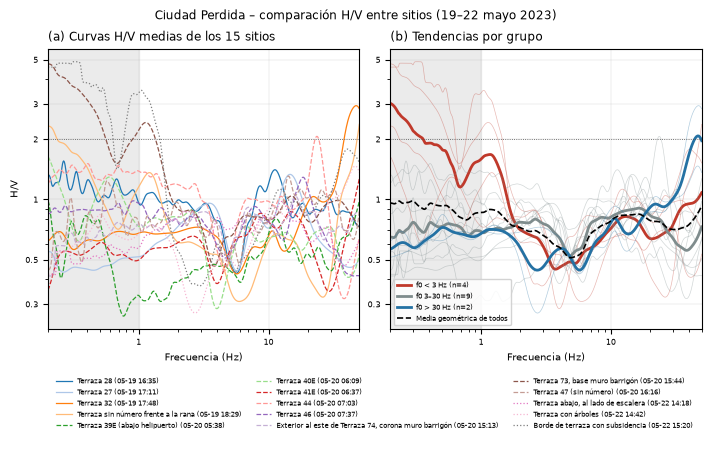

In [4]:
def group(row):
    if row['f0'] < 3:
        return 'f0 < 3 Hz'
    if row['f0'] > 30:
        return 'f0 > 30 Hz'
    return 'f0 3–30 Hz'
recomputed['Grupo'] = recomputed.apply(group, axis=1)
GROUP_COLORS = {'f0 < 3 Hz': '#c0392b', 'f0 3–30 Hz': '#7f8c8d', 'f0 > 30 Hz': '#2471a3'}
DAY_STYLES = {'2023-05-19': '-', '2023-05-20': '--', '2023-05-22': ':'}

common = np.geomspace(0.2, 50, 600)
matrix = pd.DataFrame({sid: np.interp(np.log(common), np.log(c.index), c.values) for sid, c in curves.items()}, index=common)

STYLE = hp.PaperStyle(width_in=7.0, font_size=7, tick_size=6, legend_size=5.5, dpi=300)
with plt.rc_context({'font.size': 7, 'axes.labelsize': 7, 'xtick.labelsize': 6, 'ytick.labelsize': 6, 'legend.fontsize': 5.5}):
    fig = plt.figure(figsize=(7.0, 4.4), layout='constrained')
    gs = fig.add_gridspec(2, 2, height_ratios=[3.0, 0.75])
    axes = [fig.add_subplot(gs[0, 0])]
    axes.append(fig.add_subplot(gs[0, 1], sharey=axes[0]))
    leg_ax = fig.add_subplot(gs[1, :])
    leg_ax.axis('off')
    ax = axes[0]
    cmap = plt.get_cmap('tab20')
    for i, r in recomputed.iterrows():
        ax.plot(common, matrix[r['session_id']], color=cmap(i % 20), lw=0.9,
                ls=DAY_STYLES[r['Inicio'][:10]], label=f"{r['Lugar (bitácora)']} ({r['Inicio'][5:]})")
    ax.set_title('(a) Curvas H/V medias de los 15 sitios', loc='left')
    leg_ax.legend(*ax.get_legend_handles_labels(), loc='upper center', ncol=3, frameon=False, fontsize=5, handlelength=2.2)

    ax = axes[1]
    for g, color in GROUP_COLORS.items():
        ids = recomputed.loc[recomputed['Grupo'] == g, 'session_id']
        for sid in ids:
            ax.plot(common, matrix[sid], color=color, lw=0.5, alpha=0.35)
        gm = np.exp(np.log(matrix[ids]).mean(axis=1))
        ax.plot(common, gm, color=color, lw=2.0, label=f'{g} (n={len(ids)})')
    gm_all = np.exp(np.log(matrix).mean(axis=1))
    ax.plot(common, gm_all, color='k', lw=1.2, ls='--', label='Media geométrica de todos')
    ax.set_title('(b) Tendencias por grupo', loc='left')
    ax.legend(loc='lower left', fontsize=5, frameon=True, framealpha=0.85)

    for ax in axes:
        ax.set_xscale('log'); ax.set_yscale('log')
        ax.set_xlim(0.2, 50)
        ax.axhline(2, color='0.3', lw=0.6, ls=':')
        ax.axvspan(0.2, 1.0, color='0.92', zorder=0)
        ax.set_xlabel('Frecuencia (Hz)')
        ax.grid(True, which='major', lw=0.3, alpha=0.5)
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:g}'))
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:g}'))
        ax.yaxis.set_minor_formatter(plt.NullFormatter())
        ax.set_yticks([0.3, 0.5, 1, 2, 3, 5])
    axes[0].set_ylabel('H/V')
    fig.suptitle('Ciudad Perdida – comparación H/V entre sitios (19–22 mayo 2023)')
    for ext in ('png', 'pdf', 'svg'):
        fig.savefig(OUTPUT_DIR / f'hvsr_site_comparison.{ext}', dpi=300, bbox_inches='tight')
    plt.show()

## Mapa de calor

Cada fila es un sitio ordenado por fecha y hora, y el color es log10(H/V). Sirve para ver bandas de frecuencia que se repiten entre sitios.

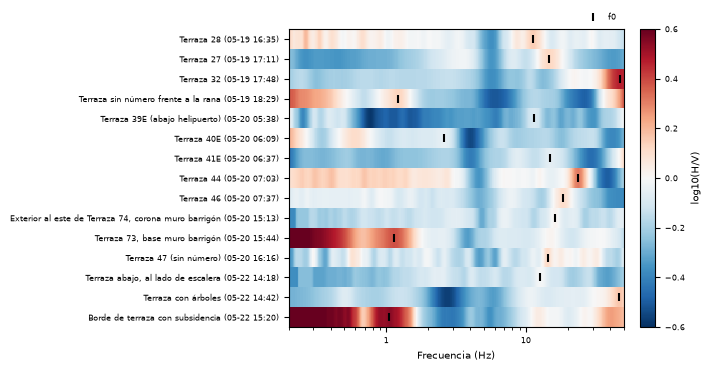

In [5]:
with plt.rc_context({'font.size': 7, 'xtick.labelsize': 6, 'ytick.labelsize': 6}):
    fig, ax = plt.subplots(figsize=(7.0, 3.6), layout='constrained')
    data = np.log10(matrix[recomputed['session_id']].T.values)[:, :-1]
    mesh = ax.pcolormesh(common, np.arange(len(recomputed) + 1), data, cmap='RdBu_r', vmin=-0.6, vmax=0.6, shading='flat')
    ax.set_xscale('log'); ax.set_xlim(0.2, 50)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:g}'))
    ax.set_yticks(np.arange(len(recomputed)) + 0.5)
    ax.set_yticklabels([f"{r['Lugar (bitácora)']} ({r['Inicio'][5:]})" for _, r in recomputed.iterrows()])
    ax.invert_yaxis()
    ax.scatter(recomputed['f0'], np.arange(len(recomputed)) + 0.5, marker='|', color='k', s=40, label='f0', zorder=3)
    ax.set_xlabel('Frecuencia (Hz)')
    fig.colorbar(mesh, ax=ax, label='log10(H/V)')
    ax.legend(loc='upper right', bbox_to_anchor=(1, 1.08), fontsize=6, frameon=False)
    for ext in ('png', 'pdf', 'svg'):
        fig.savefig(OUTPUT_DIR / f'hvsr_site_heatmap.{ext}', dpi=300, bbox_inches='tight')
    plt.show()

In [6]:
band_stats = []
for lo, hi in [(0.2, 1), (1, 3), (3, 10), (10, 30), (30, 50)]:
    sel = (common >= lo) & (common < hi)
    for g in GROUP_COLORS:
        ids = recomputed.loc[recomputed['Grupo'] == g, 'session_id']
        band_stats.append({'Banda (Hz)': f'{lo}–{hi}', 'Grupo': g,
                           'H/V mediana': float(np.median(matrix.loc[sel, ids].values))})
band_table = pd.DataFrame(band_stats).pivot(index='Banda (Hz)', columns='Grupo', values='H/V mediana')
display(band_table.round(2))
display(recomputed.groupby('Grupo')['Lugar (bitácora)'].apply(list))
matrix.rename(columns=site_of).to_csv(OUTPUT_DIR / 'hvsr_mean_curves.csv', index_label='frequency_hz')
recomputed.to_csv(OUTPUT_DIR / 'hvsr_site_peaks.csv', index=False)
print('Guardado en', OUTPUT_DIR.relative_to(ROOT))

Grupo,f0 3–30 Hz,f0 < 3 Hz,f0 > 30 Hz
Banda (Hz),,,
0.2–1,0.68,1.74,0.64
10–30,0.84,0.75,0.86
1–3,0.77,0.84,0.68
30–50,0.59,0.97,1.37
3–10,0.71,0.54,0.54


Grupo
f0 3–30 Hz    [Terraza 28, Terraza 27, Terraza 39E (abajo he...
f0 < 3 Hz     [Terraza sin número frente a la rana, Terraza ...
f0 > 30 Hz                    [Terraza 32, Terraza con árboles]
Name: Lugar (bitácora), dtype: object

Guardado en outputs/site_comparison


## Tendencias observadas

1. **Mínimo común entre 4 y 6 Hz.** Casi todas las curvas bajan a H/V ≈ 0.4–0.6 en la misma banda, sin importar el sitio ni el día. Un rasgo tan uniforme apunta a una causa común: el mismo equipo y montaje, una respuesta propia de la componente vertical, o un rasgo regional del macizo. No parece un efecto local de cada terraza.
2. **H/V menor que 1 en casi toda la banda.** La media geométrica de todos los sitios está entre 0.5 y 1. Eso significa que la componente vertical domina, lo que es típico de sitios rígidos sin un contraste somero. También puede venir de diferencias de ganancia o de unidades entre componentes, que todavía no están verificadas.
3. **Por debajo de ≈1.5 Hz se separan cuatro sitios.** El borde con subsidencia, la base del muro barrigón de la T73 y, en menor medida, la terraza frente a la rana y la 40E suben hacia frecuencias bajas: la mediana en 0.2–1 Hz es ≈1.7 frente a ≈0.7 en el resto. El "pico de 1 Hz" está sobre ese flanco ascendente y no es un máximo aislado. La corona del mismo muro barrigón no muestra esa subida.
4. **Subida por encima de 30 Hz.** Aparece en la Terraza 32, la terraza con árboles, la terraza frente a la rana y la de subsidencia. Puede reflejar rellenos superficiales muy delgados o el acople del sensor. No se puede separar de los efectos instrumentales sin un muestreo mayor.
5. **Entre 8 y 20 Hz hay ondulaciones con H/V ≈ 1–1.4** (Terrazas 28, 27, 46, 47). La amplitud es baja, así que no son resonancias significativas.

Conclusión: la plataforma de terrazas responde como un sitio rígido. La única tendencia que diferencia sitios es la subida de H/V a baja frecuencia en los puntos con deformación (subsidencia y base del muro barrigón), y eso la convierte en la hipótesis principal a verificar en campo.